# Chapter 11: Novelty and Outlier Detection

Reproduksi dan pembahasan buku John Sukup, *scikit-learn Cookbook*, Third Edition (Packt, 2025). Kode diadaptasi dari [repo penerbit](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500/Chapter_11) beserta exercise solutions. Adaptasi metodologi dijelaskan pada bagian terkait. Dataset sintetis/bawaan dan output di bawah dipakai untuk memahami workflow pembelajaran mesin.

## Daftar Isi

- [Introduction to Outlier and Novelty Detection](#introduction-to-outlier-and-novelty-detection)
- [Understanding Isolation Forest](#understanding-isolation-forest)
- [One-Class SVM for Novelty Detection](#one-class-svm-for-novelty-detection)
- [Detecting Outliers with LOF](#detecting-outliers-with-lof)
- [Evaluating Outlier Detection Models](#evaluating-outlier-detection-models)
- [Handling Detected Outliers](#handling-detected-outliers)
- [Choosing the Right Detection Technique](#choosing-the-right-detection-technique)
- [Practical Exercises in Novelty and Outlier Detection](#practical-exercises-in-novelty-and-outlier-detection)
- [Pemeriksaan Hasil](#pemeriksaan-hasil)
- [Ringkasan Bab](#ringkasan-bab)

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
np.random.seed(2024)
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 25)
plt.rcParams.update({'figure.dpi': 100, 'savefig.bbox': 'tight'})
chapter_results = {}

from sklearn.metrics import f1_score, recall_score

## Introduction to Outlier and Novelty Detection

Outlier detection mencari penyimpangan dalam data training yang mungkin sudah tercemar. Novelty detection belajar dari data normal lalu menilai sampel baru. Output scikit-learn umumnya +1 untuk inlier dan -1 untuk anomali. Label evaluasi di sini memakai 0 normal, 1 anomali sehingga perlu konversi eksplisit.

Anomali statistik tidak otomatis kesalahan data atau fraud. Outlier dapat berasal dari error, kasus langka yang sah, atau perubahan distribusi. Contoh awal mencampur 300 titik normal dengan 20 titik uniform lalu menggunakan LOF. Contamination mengatur ambang perkiraan proporsi anomali; tidak memulihkan jumlah anomali sebenarnya secara pasti.

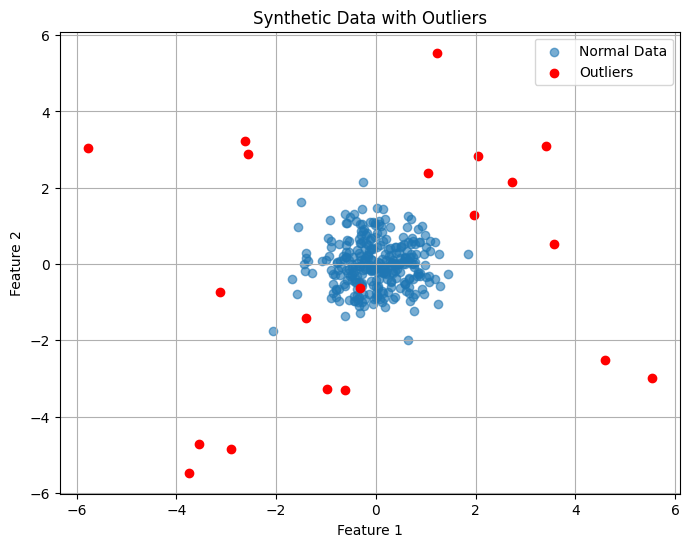

In [2]:
# Load the libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate a synthetic dataset with intentional outliers
X, _ = make_blobs(n_samples=300, centers=[[0, 0]], cluster_std=0.60, random_state=2024)
np.random.seed(2024)
outliers = np.random.uniform(low=-6, high=6, size=(20, 2))
X_with_outliers = np.vstack([X, outliers])

# Visualize the data with outliers
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], label="Normal Data", alpha=0.6)
plt.scatter(outliers[:, 0], outliers[:, 1], color='red', label="Outliers")
plt.title("Synthetic Data with Outliers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

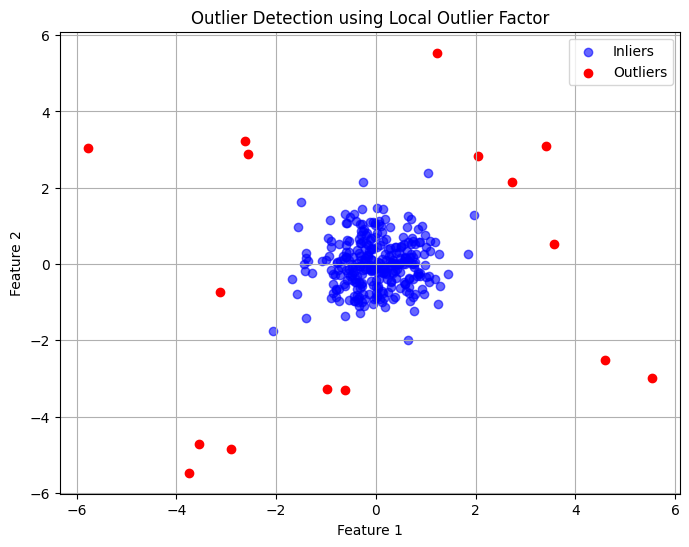

In [3]:
# Load the model
from sklearn.neighbors import LocalOutlierFactor

# Fit the model and predict outliers
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred = lof.fit_predict(X_with_outliers)

# Plot the predictions
plt.figure(figsize=(8, 6))
plt.scatter(X_with_outliers[y_pred == 1, 0], X_with_outliers[y_pred == 1, 1],
            color='blue', label='Inliers', alpha=0.6)
plt.scatter(X_with_outliers[y_pred == -1, 0], X_with_outliers[y_pred == -1, 1],
            color='red', label='Outliers')
plt.title("Outlier Detection using Local Outlier Factor")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

chapter_results['initial_lof_outliers'] = int(np.sum(y_pred == -1))

## Understanding Isolation Forest

Isolation Forest memilih fitur dan split acak untuk mengisolasi pengamatan. Sampel yang terisolasi dengan path pendek cenderung lebih abnormal. Banyak pohon merata-ratakan estimasi dan subsampling membantu biaya komputasi. Contamination menentukan threshold; score ranking dan keputusan binary adalah dua hal berbeda.

Model tidak menggunakan label anomali saat fit. Skala, fitur tidak relevan, dan struktur multikelompok tetap dapat memengaruhi hasil, sehingga klaim “selalu baik di dimensi tinggi” terlalu kuat. Grafik memperlihatkan keputusan pada training yang tercemar, bukan holdout novelty.

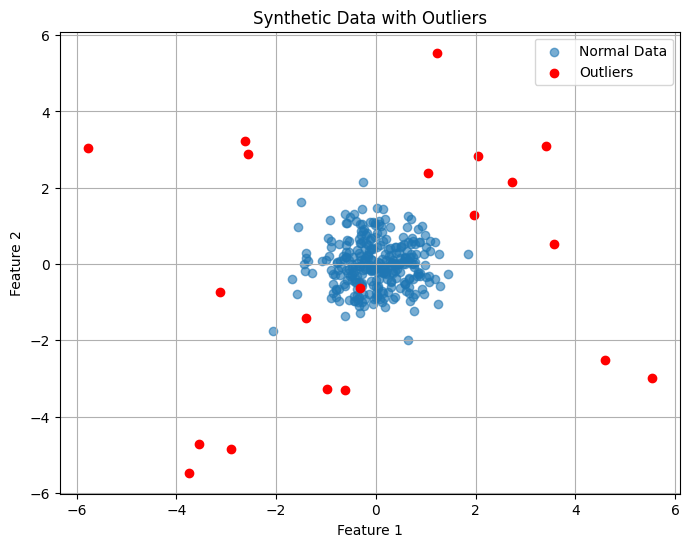

In [4]:
# Load the libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs

# Generate synthetic data with outliers
X, _ = make_blobs(n_samples=300, centers=[[0, 0]], cluster_std=0.6, random_state=2024)
np.random.seed(2024)
outliers = np.random.uniform(low=-6, high=6, size=(20, 2))
X_combined = np.vstack([X, outliers])

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], label="Normal Data", alpha=0.6)
plt.scatter(outliers[:, 0], outliers[:, 1], color='red', label="Outliers")
plt.title("Synthetic Data with Outliers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

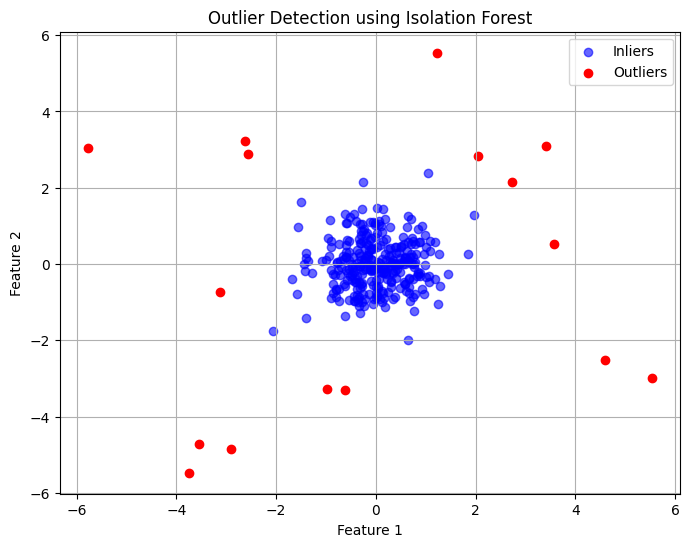

In [5]:
# Load and configure the model
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=2024)

# Fit the model and make predictions
model.fit(X_combined)
y_pred = model.predict(X_combined)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X_combined[y_pred == 1, 0], X_combined[y_pred == 1, 1],
            color='blue', label='Inliers', alpha=0.6)
plt.scatter(X_combined[y_pred == -1, 0], X_combined[y_pred == -1, 1],
            color='red', label='Outliers')
plt.title("Outlier Detection using Isolation Forest")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## One-Class SVM for Novelty Detection

OneClassSVM mempelajari batas dukungan data normal di feature space kernel. RBF gamma mengatur kelokalan batas; nu membatasi proporsi training error dari atas dan proporsi support vectors dari bawah pada kondisi optimasi standar. Nu bukan target recall anomali.

Data normal training dan test dibuat dari pusat serta sebaran yang sama. Sumber menggunakan pusat berbeda pada test normal sehingga label “normal” tidak sesuai distribusi training; hal itu diperbaiki. Titik uniform tetap dapat jatuh dekat pusat normal, sehingga label proses pembangkitan tidak menjamin setiap titik mudah dideteksi. Novelty dinilai pada data baru, bukan training.

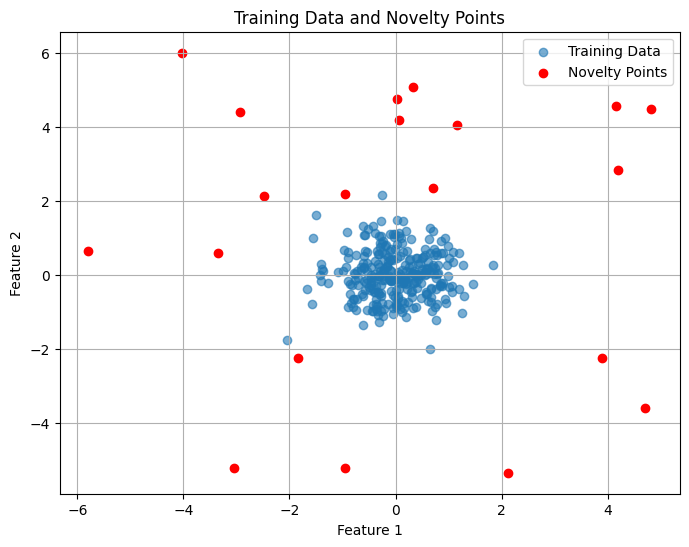

In [6]:
# Load the libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Generate training data (normal only)
X_train, _ = make_blobs(n_samples=300, centers=[[0, 0]], cluster_std=0.6, random_state=2024)

# Generate test data (normal + novelty)
X_test_normal, _ = make_blobs(n_samples=100, centers=[[0, 0]], cluster_std=0.6, center_box=(0, 1), random_state=42)
X_test_novelty = np.random.uniform(low=-6, high=6, size=(20, 2))
X_test = np.vstack([X_test_normal, X_test_novelty])

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], label='Training Data', alpha=0.6)
plt.scatter(X_test_novelty[:, 0], X_test_novelty[:, 1], color='red', label='Novelty Points')
plt.title("Training Data and Novelty Points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

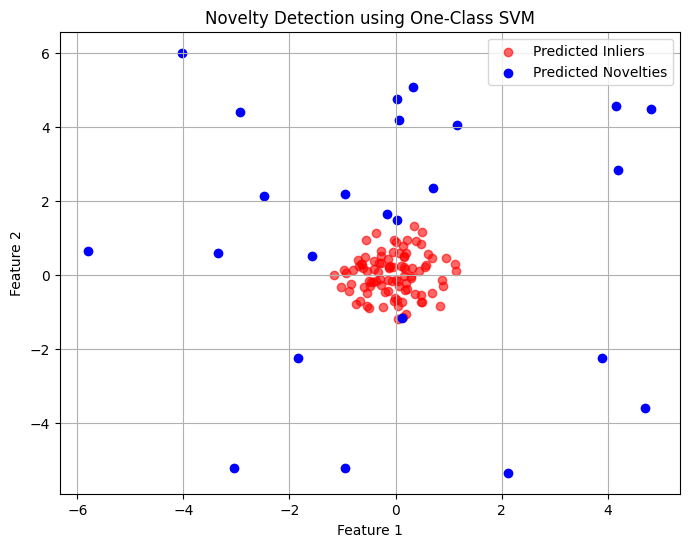

In [7]:
# Instantiate and fit the model
model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
model.fit(X_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Plot the predictions
plt.figure(figsize=(8, 6))
plt.scatter(X_test[y_pred == 1, 0], X_test[y_pred == 1, 1], color='red', label='Predicted Inliers', alpha=0.6)
plt.scatter(X_test[y_pred == -1, 0], X_test[y_pred == -1, 1], color='blue', label='Predicted Novelties')
plt.title("Novelty Detection using One-Class SVM")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

chapter_results['ocsvm_normal_false_positive_rate'] = float(np.mean(y_pred[:100] == -1))
chapter_results['ocsvm_novelty_recall'] = float(np.mean(y_pred[100:] == -1))

## Detecting Outliers with LOF

Local Outlier Factor membandingkan local reachability density suatu titik dengan density tetangganya. Dengan demikian, penyimpangan lokal dapat terlihat meskipun cluster mempunyai density berbeda. n_neighbors menentukan skala lokal; dimensi tinggi, jarak yang buruk, dan kelompok anomali yang padat dapat mengganggu hasil.

Mode default memakai fit_predict pada dataset yang sama dan menyediakan negative_outlier_factor_. Untuk data baru gunakan novelty=True saat membuat estimator, fit pada data normal, lalu predict hanya pada sampel baru. Mode novelty tidak menyediakan fit_predict; menilai training dengan predict novelty menghasilkan interpretasi keliru.

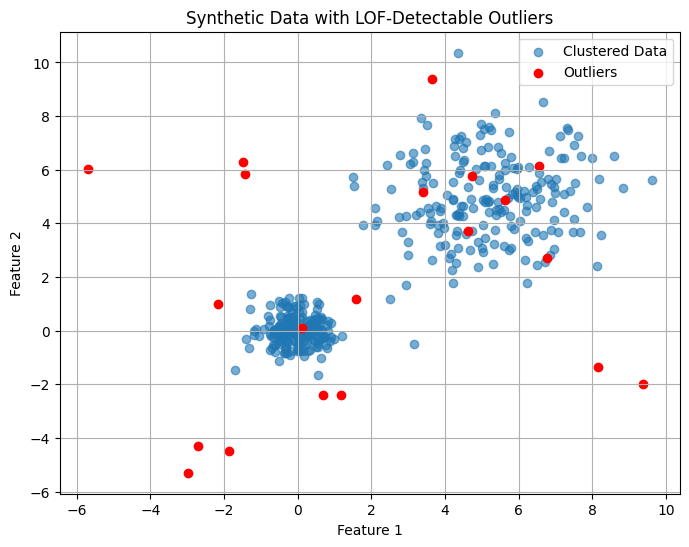

In [8]:
# Load the libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import LocalOutlierFactor

# Create synthetic data with clusters and noise
X, _ = make_blobs(n_samples=400, centers=[[0, 0], [5, 5]], cluster_std=[0.5, 1.5], random_state=2024)
np.random.seed(2024)
outliers = np.random.uniform(low=-6, high=10, size=(20, 2))
X_with_outliers = np.vstack([X, outliers])

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], label="Clustered Data", alpha=0.6)
plt.scatter(outliers[:, 0], outliers[:, 1], color='red', label="Outliers")
plt.title("Synthetic Data with LOF-Detectable Outliers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

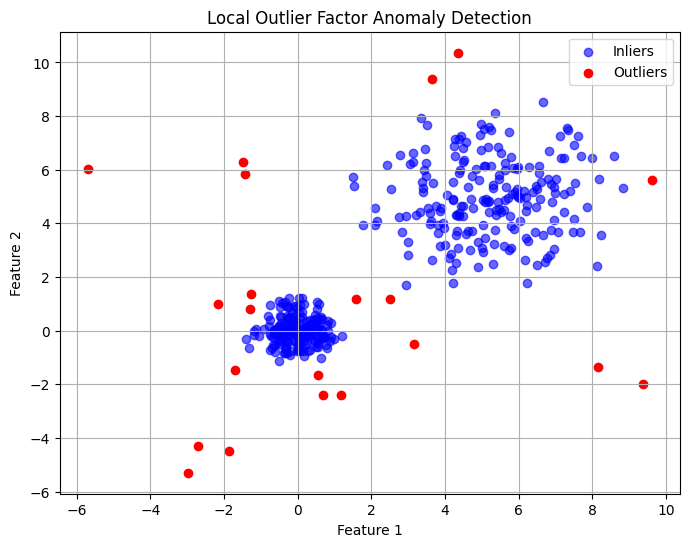

In [9]:
# Initialize and fit the model
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred = lof.fit_predict(X_with_outliers)

# Plot the predictions
plt.figure(figsize=(8, 6))
plt.scatter(X_with_outliers[y_pred == 1, 0], X_with_outliers[y_pred == 1, 1],
            color='blue', label='Inliers', alpha=0.6)
plt.scatter(X_with_outliers[y_pred == -1, 0], X_with_outliers[y_pred == -1, 1],
            color='red', label='Outliers')
plt.title("Local Outlier Factor Anomaly Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Evaluating Outlier Detection Models

Precision menjawab berapa alarm yang benar, recall berapa anomali terdeteksi, dan F1 menyeimbangkan keduanya. Accuracy dapat terlihat tinggi bila anomali langka. ROC-AUC menilai ranking skor; karena label positif di sini adalah anomali, skor harus lebih besar untuk sampel abnormal. IsolationForest.decision_function lebih besar untuk normal sehingga AUC memakai tanda negatif.

Confusion matrix dan report contoh ini mendeskripsikan dataset tercemar yang dipakai fit; bukan estimasi generalisasi independen. Threshold ditetapkan melalui contamination, sedangkan biaya false alarm dan missed anomaly perlu disesuaikan dengan aplikasi. PR-AUC dapat lebih informatif pada kejadian sangat langka.

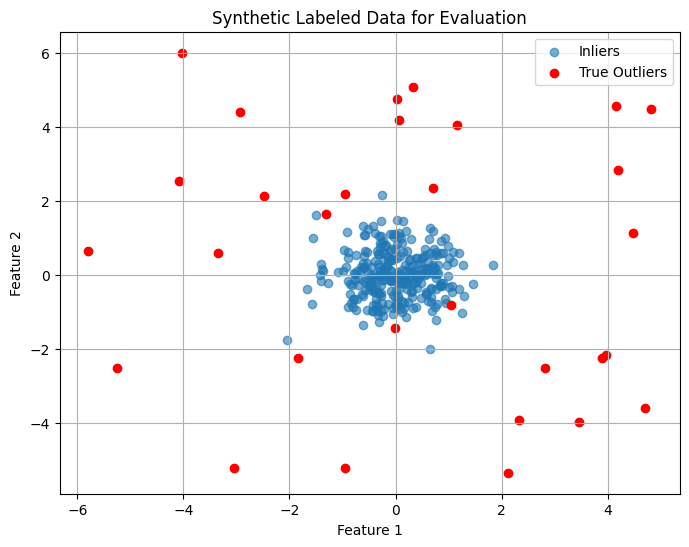

In [10]:
# Load the libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# Generate labeled synthetic data
X_inliers, _ = make_blobs(n_samples=300, centers=[[0, 0]], cluster_std=0.6, random_state=2024)
X_outliers = np.random.uniform(low=-6, high=6, size=(30, 2))
X = np.vstack([X_inliers, X_outliers])
y_true = np.array([0] * len(X_inliers) + [1] * len(X_outliers))  # 0 = inlier, 1 = outlier

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[y_true == 0][:, 0], X[y_true == 0][:, 1], label='Inliers', alpha=0.6)
plt.scatter(X[y_true == 1][:, 0], X[y_true == 1][:, 1], color='red', label='True Outliers')
plt.title("Synthetic Labeled Data for Evaluation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

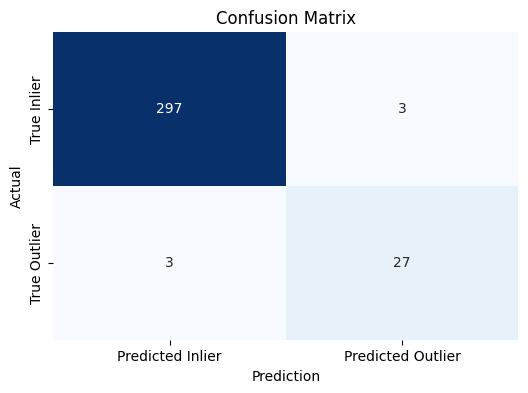

,precision,recall,f1-score,support
0,0.990,0.990,0.990,300
1,0.900,0.900,0.900,30
accuracy,0.982,0.982,0.982,1
macro avg,0.945,0.945,0.945,330
weighted avg,0.982,0.982,0.982,330


ROC-AUC Score: 0.9948888888888889


In [11]:
import pandas as pd

# Fit the model and get predictions
model = IsolationForest(contamination=0.09, random_state=2024)
model.fit(X)
y_pred = model.predict(X)
y_pred_binary = np.where(y_pred == 1, 0, 1)  # convert to 0 = inlier, 1 = outlier

# Generate and plot confusion matrix
cm = confusion_matrix(y_true, y_pred_binary)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Inlier', 'Predicted Outlier'],
            yticklabels=['True Inlier', 'True Outlier'])
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print classification report as a styled DataFrame and AUC
report = classification_report(y_true, y_pred_binary, output_dict=True, zero_division=0)
report = pd.DataFrame(report).transpose()
styled_report = (report
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_report)
print("ROC-AUC Score:", roc_auc_score(y_true, -model.decision_function(X)))

chapter_results['isolation_training_auc'] = roc_auc_score(y_true, -model.decision_function(X))
chapter_results['isolation_training_f1'] = f1_score(y_true, y_pred_binary, zero_division=0)
assert cm.sum() == len(X)

## Handling Detected Outliers

Pilihan meliputi pemeriksaan manual, mempertahankan kasus sah, menghapus error, mengganti nilai, capping/winsorization, atau memakai model robust. Penghapusan dapat membuat bias seleksi dan menghilangkan kasus penting. Median replacement mengubah seluruh vektor terdeteksi dan dapat menciptakan massa data artifisial; clipping per fitur tidak sama dengan memperbaiki penyebab outlier multivariat.

Contoh removal, replacement, dan capping hanya mendemonstrasikan mekanisme pada data sintetis. Dalam pipeline prediksi, threshold, quantile, dan median dipelajari pada training saja. Test tidak boleh dibuang berdasarkan label atau hasilnya agar metrik tampak lebih bagus.

In [12]:
# Load the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs

# Generate the dataset
X_inliers, _ = make_blobs(n_samples=300, centers=[[0, 0]], cluster_std=0.6, random_state=2024)
X_outliers = np.random.uniform(low=-6, high=6, size=(30, 2))
X = np.vstack([X_inliers, X_outliers])

#  Detect outliers using Isolation Forest
model = IsolationForest(contamination=0.09, random_state=2024)
model.fit(X)
outlier_mask = model.predict(X) == -1

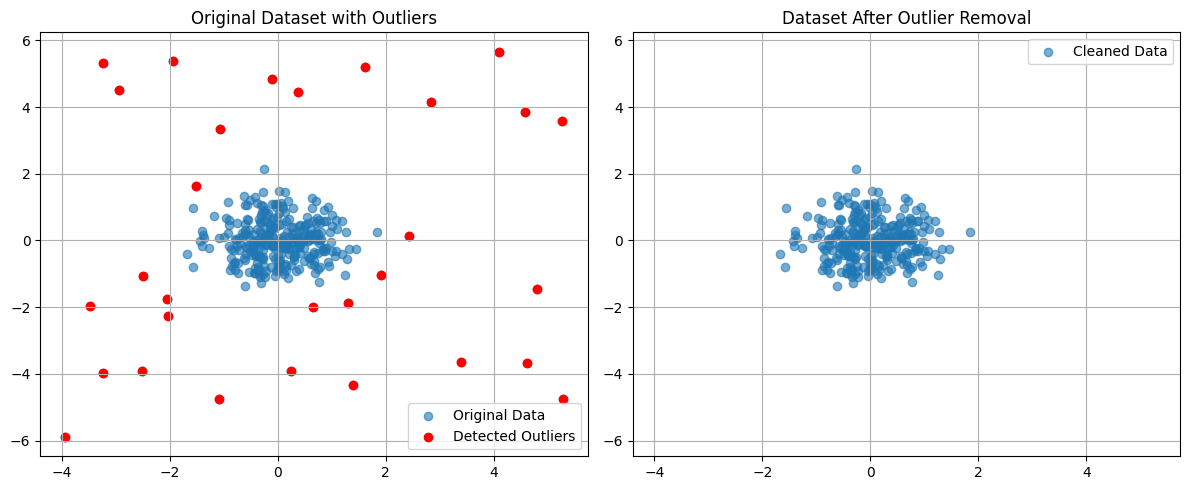

In [13]:
# Remove outliers from the dataset
X_cleaned = X[~outlier_mask]

# Replace outliers with the feature-wise median
X_replaced = X.copy()
median_vals = np.median(X[~outlier_mask], axis=0)
X_replaced[outlier_mask] = median_vals

# Cap outliers to specified bounds (winsorization)
X_df = pd.DataFrame(X, columns=['feature1', 'feature2'])
X_capped = X_df.copy()
for col in X_df.columns:
    lower = X_df[col].quantile(0.05)
    upper = X_df[col].quantile(0.95)
    X_capped[col] = X_df[col].clip(lower=lower, upper=upper)

# Visualize original and cleaned datasets with matched axes
plt.figure(figsize=(12, 5))

ax1 = plt.subplot(1, 2, 1)
ax1.scatter(X[:, 0], X[:, 1], label='Original Data', alpha=0.6)
ax1.scatter(X[outlier_mask][:, 0], X[outlier_mask][:, 1], color='red', label='Detected Outliers')
ax1.set_title('Original Dataset with Outliers')
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 2, 2)
ax2.scatter(X_cleaned[:, 0], X_cleaned[:, 1], label='Cleaned Data', alpha=0.6)
ax2.set_title('Dataset After Outlier Removal')
ax2.legend()
ax2.grid(True)

ax2.set_xlim(ax1.get_xlim())
ax2.set_ylim(ax1.get_ylim())

plt.tight_layout()
plt.show()

assert len(X_cleaned) == len(X) - outlier_mask.sum()
chapter_results['removed_rows'] = int(outlier_mask.sum())

## Choosing the Right Detection Technique

Isolation Forest sering menjadi baseline untuk data besar; LOF menilai density lokal; One-Class SVM memodelkan batas normal berbasis kernel. Semua belajar tanpa label kelas, walaupun novelty detection mengasumsikan training diketahui normal. Tabel sumber yang mengatakan One-Class SVM tidak belajar dari unlabeled data dan LOF tidak pernah mendukung predict diperbaiki.

Pemilihan bergantung pada distribusi normal, representasi, biaya komputasi, kebutuhan data baru, dan ambang alarm yang dapat ditindaklanjuti. Membandingkan precision/recall pada data berlabel terpisah lebih kuat daripada memilih dari grafik saja.

In [14]:
summary_df = pd.DataFrame({
    'Algorithm': ['Isolation Forest', 'Local Outlier Factor', 'One-Class SVM'],
    'Training labels': ['Tidak diperlukan', 'Tidak diperlukan', 'Tidak diperlukan; normal diasumsikan'],
    'Data baru': ['predict tersedia', 'novelty=True; hanya data baru', 'predict tersedia'],
    'Kekuatan': ['Isolasi acak; baseline skalabel', 'Penyimpangan density lokal', 'Batas dukungan normal berbasis kernel'],
    'Batas': ['Fitur dan distribusi tetap memengaruhi', 'Sensitif n_neighbors dan metrik jarak', 'Sensitif skala, kernel; biaya data besar'],
}).set_index('Algorithm')
display(summary_df)

,Training labels,Data baru,Kekuatan,Batas
Algorithm,,,,
Isolation Forest,Tidak diperlukan,predict tersedia,Isolasi acak; baseline skalabel,Fitur dan distribusi tetap memengaruhi
Local Outlier Factor,Tidak diperlukan,novelty=True; hanya data baru,Penyimpangan density lokal,Sensitif n_neighbors dan metrik jarak
One-Class SVM,Tidak diperlukan; normal diasumsikan,predict tersedia,Batas dukungan normal berbasis kernel,"Sensitif skala, kernel; biaya data besar"


In [15]:
# If your data is large and high-dimensional, consider:
# Isolation Forest is preferred
model = IsolationForest(contamination=0.1, random_state=2024)

#If your data has clusters with varying densities:
# Local Outlier Factor is better suited
model = LocalOutlierFactor(n_neighbors=20, contamination=0.1)

# If you want to train on only normal data and detect novel data points later:
# One-Class SVM enables novelty detection
model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1)

## Practical Exercises in Novelty and Outlier Detection

Exercise 1 memakai data Gaussian + uniform dan Isolation Forest. Meskipun judul buku menyebut real-world, dataset kode adalah sintetis dan tidak diklaim sebagai kasus nyata. Exercise 2 mensimulasikan dua kelompok dengan density berbeda sebagai ilustrasi intrusion; ini bukan log jaringan asli. Keduanya menilai deteksi pada dataset tercemar yang sama.

Exercise 3 mensimulasikan sensor manufacturing normal, menyisihkan sebagian normal sebagai holdout, menambahkan novelty, lalu menilai One-Class SVM. Recall dan false-positive rate dihitung terpisah; skor simulasi tidak membuktikan sistem sensor atau fraud siap dipakai.

In [16]:
# Load libraries
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.datasets import make_blobs

# Generate synthetic data with inliers and outliers
X_inliers, _ = make_blobs(n_samples=300, centers=[[0, 0]], cluster_std=0.6, random_state=2024)
X_outliers = np.random.uniform(low=-6, high=6, size=(30, 2))
X = np.vstack([X_inliers, X_outliers])
y_true = np.array([0] * len(X_inliers) + [1] * len(X_outliers))

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply Isolation Forest
model = IsolationForest(contamination=0.09, random_state=2024)
model.fit(X_scaled)
y_pred = model.predict(X_scaled)
y_pred_binary = np.where(y_pred == 1, 0, 1)

# Evaluate the results
print("Exercise 1 Results:")

# Print classification report as a styled DataFrame
report = classification_report(y_true, y_pred_binary, output_dict=True, zero_division=0)
report = pd.DataFrame(report).transpose()
styled_report = (report
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_report)

chapter_results['exercise_isolation_f1'] = f1_score(y_true, y_pred_binary, zero_division=0)

Exercise 1 Results:


,precision,recall,f1-score,support
0,0.993,0.993,0.993,300
1,0.933,0.933,0.933,30
accuracy,0.988,0.988,0.988,1
macro avg,0.963,0.963,0.963,330
weighted avg,0.988,0.988,0.988,330



Exercise 2 Results:


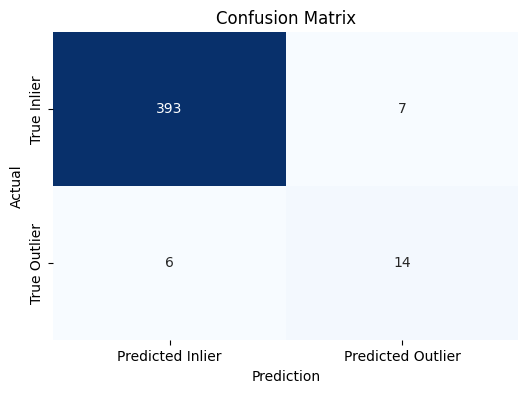

,precision,recall,f1-score,support
0,0.985,0.983,0.984,400
1,0.667,0.700,0.683,20
accuracy,0.969,0.969,0.969,1
macro avg,0.826,0.841,0.833,420
weighted avg,0.970,0.969,0.969,420


In [17]:
# Load libraries
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Generate clustered data with synthetic noise
X_clustered, _ = make_blobs(n_samples=400, centers=[[0, 0], [5, 5]], cluster_std=[0.5, 1.5], random_state=2024)
X_noise = np.random.uniform(low=-6, high=10, size=(20, 2))
X_combined = np.vstack([X_clustered, X_noise])
y_combined = np.array([0] * 400 + [1] * 20)

# Scale the data
X_scaled = scaler.fit_transform(X_combined)

# Apply Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred = lof.fit_predict(X_scaled)
y_pred_binary = np.where(y_pred == 1, 0, 1)

# Evaluate the predictions
print("\nExercise 2 Results:")
cm = confusion_matrix(y_combined, y_pred_binary)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Inlier', 'Predicted Outlier'],
            yticklabels=['True Inlier', 'True Outlier'])
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

report = classification_report(y_combined, y_pred_binary, output_dict=True, zero_division=0)
report = pd.DataFrame(report).transpose()
styled_report = (report
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_report)

chapter_results['exercise_lof_f1'] = f1_score(y_combined, y_pred_binary, zero_division=0)

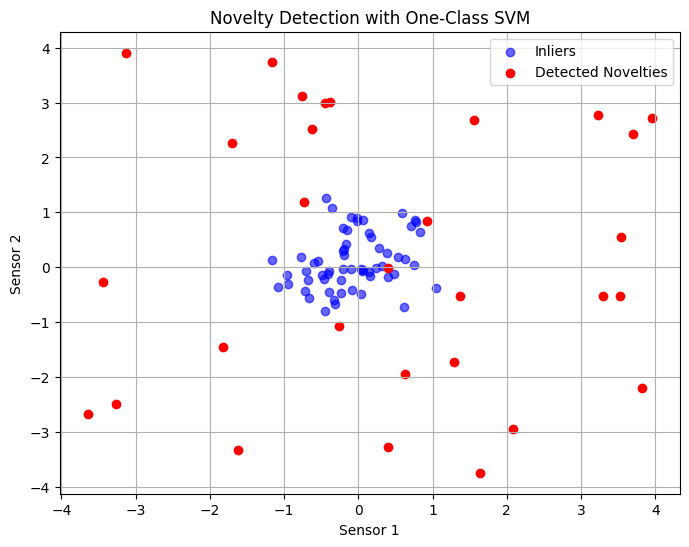

In [18]:
# Load libraries
from sklearn.svm import OneClassSVM
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Generate normal and novel data
X_normal = np.random.normal(loc=0.0, scale=0.5, size=(300, 2))
X_novelty = np.random.uniform(low=-4, high=4, size=(30, 2))
X_train, X_test = train_test_split(X_normal, test_size=0.2, random_state=2024)
X_eval = np.vstack([X_test, X_novelty])

# Fit One-Class SVM on normal data
svm_model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
svm_model.fit(X_train)
y_pred = svm_model.predict(X_eval)

# Visualize predictions
plt.figure(figsize=(8, 6))
plt.scatter(X_eval[y_pred == 1][:, 0], X_eval[y_pred == 1][:, 1], color='blue', label='Inliers', alpha=0.6)
plt.scatter(X_eval[y_pred == -1][:, 0], X_eval[y_pred == -1][:, 1], color='red', label='Detected Novelties')
plt.title("Novelty Detection with One-Class SVM")
plt.xlabel("Sensor 1")
plt.ylabel("Sensor 2")
plt.legend()
plt.grid(True)
plt.show()

chapter_results['exercise_sensor_false_positive_rate'] = float(np.mean(y_pred[:len(X_test)] == -1))
chapter_results['exercise_sensor_recall'] = float(np.mean(y_pred[len(X_test):] == -1))

### Pemeriksaan Tambahan

Contoh LOF novelty menilai hanya data baru dan melaporkan recall serta false-positive rate.

In [19]:
# LOF novelty mode: train only on normal data; evaluate only new samples.
rng = np.random.default_rng(2024)
normal = rng.normal(0, 0.6, (300, 2))
new_normal = rng.normal(0, 0.6, (100, 2))
new_anomalies = rng.uniform(3, 6, (20, 2))
novelty_lof = make_pipeline(StandardScaler(), LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.05))
novelty_lof.fit(normal)
new_data = np.vstack([new_normal, new_anomalies])
true_anomaly = np.r_[np.zeros(100, dtype=int), np.ones(20, dtype=int)]
predicted_anomaly = (novelty_lof.predict(new_data) == -1).astype(int)
chapter_results['lof_novelty_recall'] = recall_score(true_anomaly, predicted_anomaly)
chapter_results['lof_novelty_false_positive_rate'] = float(predicted_anomaly[:100].mean())

## Pemeriksaan Hasil

Assertion di bawah memeriksa konsistensi hasil dan keluaran, bukan membuktikan seluruh asumsi statistik.

In [20]:
assert chapter_results
assert 0 <= chapter_results['isolation_training_auc'] <= 1
assert 0 <= chapter_results['lof_novelty_recall'] <= 1
assert chapter_results['removed_rows'] > 0
print(json.dumps(chapter_results, indent=2))

{
  "initial_lof_outliers": 16,
  "ocsvm_normal_false_positive_rate": 0.04,
  "ocsvm_novelty_recall": 1.0,
  "isolation_training_auc": 0.9948888888888889,
  "isolation_training_f1": 0.9,
  "removed_rows": 30,
  "exercise_isolation_f1": 0.9333333333333333,
  "exercise_lof_f1": 0.6829268292682927,
  "exercise_sensor_false_positive_rate": 0.03333333333333333,
  "exercise_sensor_recall": 0.9333333333333333,
  "lof_novelty_recall": 1.0,
  "lof_novelty_false_positive_rate": 0.05
}


## Ringkasan Bab

Isolation Forest pada dataset tercemar yang sama menghasilkan ROC-AUC **0.995** dan F1 **0.900**; AUC memakai skor yang lebih besar untuk anomali. Ini adalah evaluasi deteksi pada training, bukan estimasi holdout. Novelty One-Class SVM pada contoh utama memiliki false-positive rate normal **4.0%** dan recall novelty **100.0%**.

Latihan sensor menghasilkan recall **93.3%** dengan false-positive rate **3.3%**. LOF novelty tambahan hanya menilai sampel baru. Contoh capping/removal adalah pilihan pengolahan, bukan alasan otomatis membuang kasus yang sah. Target belajar adalah membedakan anomali, alarm keliru, dan perubahan distribusi.